In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pickle
#import pyvisa
import time 
import os 
from datetime import datetime  
#import nysg_tools as ny
import os
import pickle
import glob as glob
from scipy.optimize import curve_fit
from matplotlib.ticker import LogLocator, LogFormatter


In [2]:
plt.style.use("default") # Debe ir antes de rcParams.update para no sobreescribir los cambios

plt.rcParams.update({
    # ---- FIGURA ----
    "figure.figsize": (7,5),
    "figure.dpi": 300,           # Alta resolución (High DPI)

    # ---- FUENTES ----
    "font.size": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # ---- EJES ----
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "axes.grid": True,
    "axes.spines.top": False,    # Sin bordes
    "axes.spines.right": False,  # Sin bordes
    "axes.spines.left": False,   # Sin bordes
    "axes.spines.bottom": False, # Sin bordes

    # ---- GRID ----
    "grid.color": "#cccccc",     # Cuadrícula gris claro
    "grid.alpha": 0.6,
    "grid.linestyle": "--",

    # ---- TICKS ----
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.bottom": False,       # Oculta las rayitas de los ejes para un look más limpio
    "ytick.left": False,

    # ---- LÍNEAS ----
    "lines.linewidth": 2.5,
    "lines.markersize": 6,

    # ---- LEYENDA ----
    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "#808080", # Detalles/Highlights en gris
    "legend.fancybox": True,

    # ---- GUARDADO ----
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[
    "#0b3fa6", "#ff7f0e", "#d62728", "#2ca02c", "#9467bd"
])

In [3]:
file_list_c_1 = sorted(glob.glob("13h_44m_16s/*.pkl"))

frequencies_c_1 = []
v1_c_1 = []
v2_c_1 = []

for file in file_list_c_1:
    # -------- extraer frecuencia del nombre --------
    filename = os.path.basename(file)
    freq = float(filename.split("_")[1].replace("Hz.pkl", ""))
    frequencies_c_1.append(freq)

    # -------- cargar datos --------
    with open(file, "rb") as f:
        data = pickle.load(f)

        # convertir strings a float
        v1_c_1.append(float(data['v1']))
        v2_c_1.append(float(data['v2']))

segments_c_1 = [
    (150140,150170, 0.5 ),
    (248275,248295, 0.7),
    (427100,427550, 1.2),
    (558640,560670,20), 
    (648850,650580,30)
]

# convertir a arrays
frequencies_c_1 = np.array(frequencies_c_1)
v1_c_1 = np.array(v1_c_1)
v2_c_1 = np.array(v2_c_1)

# lista donde guardar resultados
segmented_data_c_1 = []

for start, stop, step in segments_c_1:
    # máscara: qué datos caen en este intervalo
    mask = (frequencies_c_1 >= start) & (frequencies_c_1 <= stop)
    
    seg_freq = frequencies_c_1[mask]
    seg_v1 = v1_c_1[mask]
    seg_v2 = v2_c_1[mask]
    
    segmented_data_c_1.append({
        "range": (start, stop),
        "freq": seg_freq,
        "v1": seg_v1,
        "v2": seg_v2
    })

In [4]:
# -------- modelo lorentziano --------
def lorentzian(f, f0, gamma, A, offset):
    return offset + A / (1 + ((f - f0)/gamma)**2)

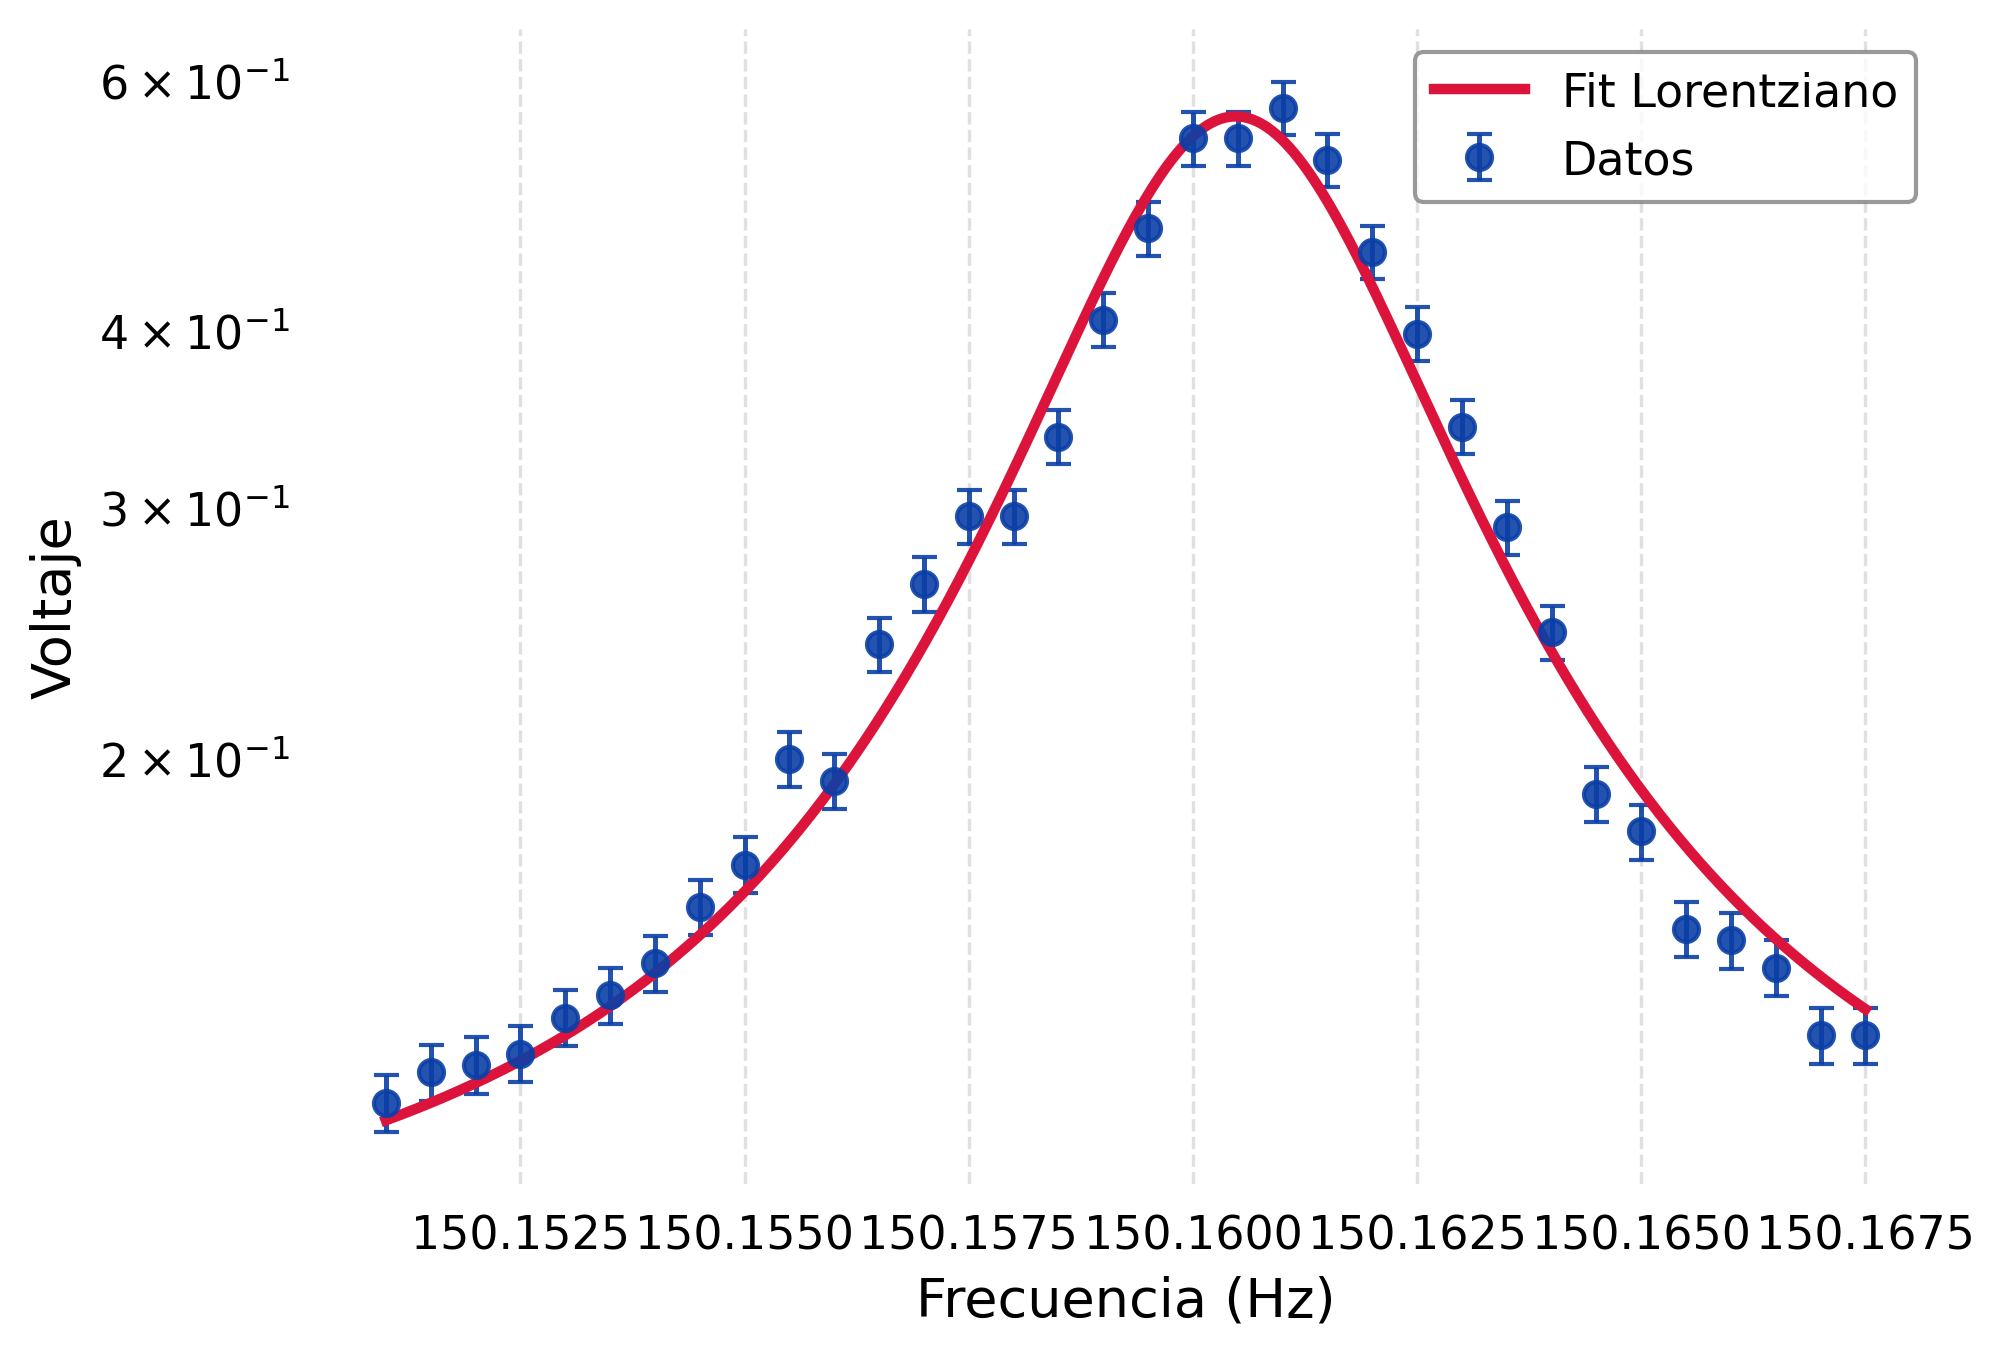

f0 = 150160.48 ± 0.04 Hz
FWHM = 4.87 ± 0.16 Hz
Q = 30862.89 ± 1026.91
Tmax = 0.566 ± 0.011 V


In [5]:
# -------- datos --------
f = np.array(segmented_data_c_1[0]["freq"])   
V2 = np.array(segmented_data_c_1[0]["v2"]) 
V1 = np.array(segmented_data_c_1[0]["v1"])     
T = V2/V1 
sigma_V2 = 0.03 * V2 + 0.001
sigma_V1 = 0.03 * V1 + 0.001

sigma_T = T * np.sqrt((sigma_V2 / V2)**2 +(sigma_V1 / V1)**2)

mask = (f > 150150.5) & (f < 150168)   

f = f[mask]
T = T[mask]
sigma_T = sigma_T[mask]

# -------- estimaciones iniciales --------
f0_guess = f[np.argmax(T)]
A_guess = max(T) - min(T)
gamma_guess = (max(f) - min(f)) / 10
offset_guess = min(T)

p0 = [f0_guess, gamma_guess, A_guess, offset_guess]

# -------- ajuste --------
popt, pcov = curve_fit(
    lorentzian,
    f,
    T,
    p0=p0,
    sigma=sigma_T,
    absolute_sigma=True,
    maxfev=10000
)

f0, gamma, A, offset = popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
df0, dgamma, dA, doffset = perr

# -------- plot --------

f_fit = np.linspace(min(f), max(f), 1000)
T_fit = lorentzian(f_fit, *popt)

plt.errorbar(
    f/1000, T,
    yerr=sigma_T,
    fmt='o',
    color='#0b3fa6',              # Azul profundo
    markerfacecolor='#0b3fa650',  # Centro semi-transparente (alpha vía Hex)
    markeredgecolor='#0b3fa6',    # Borde azul profundo
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(f_fit/1000, T_fit, '-', color='crimson', linewidth=2.5, label="Fit Lorentziano") # Rojo carmesí
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Voltaje")
plt.yscale('log')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
plt.legend()
plt.show()

f_res = f0
df_res = df0
Tmax = lorentzian(f0, *popt)
dTmax = np.sqrt(dA**2 + doffset**2)
FWHM = 2 * gamma
dFWHM = 2 * dgamma
Q = f0 / FWHM
dQ = Q * np.sqrt((df0/f0)**2 + (dFWHM/FWHM)**2)

print(f"f0 = {f0:.2f} ± {df0:.2f} Hz")
print(f"FWHM = {FWHM:.2f} ± {dFWHM:.2f} Hz")
print(f"Q = {Q:.2f} ± {dQ:.2f}")
print(f"Tmax = {Tmax:.3f} ± {dTmax:.3f} V")

In [6]:
file_list_c = sorted(glob.glob("13h_55m_38s/*.pkl"))

frequencies_c = []
v1_c = []
v2_c = []

for file in file_list_c:
    # -------- extraer frecuencia del nombre --------
    filename = os.path.basename(file)
    freq = float(filename.split("_")[1].replace("Hz.pkl", ""))
    frequencies_c.append(freq)

    # -------- cargar datos --------
    with open(file, "rb") as f:
        data = pickle.load(f)

        # convertir strings a float
        v1_c.append(float(data['v1']))
        v2_c.append(float(data['v2']))

In [7]:
segments_c = [
    (248275,248295, 0.7  ),
    (427100,427550, 1.2 ) ,
]

# convertir a arrays
frequencies_c = np.array(frequencies_c)
v1_c = np.array(v1_c)
v2_c = np.array(v2_c)

# lista donde guardar resultados
segmented_data_c = []

for start, stop, step in segments_c:
    # máscara: qué datos caen en este intervalo
    mask = (frequencies_c >= start) & (frequencies_c <= stop)
    
    seg_freq = frequencies_c[mask]
    seg_v1 = v1_c[mask]
    seg_v2 = v2_c[mask]
    
    segmented_data_c.append({
        "range": (start, stop),
        "freq": seg_freq,
        "v1": seg_v1,
        "v2": seg_v2
    })

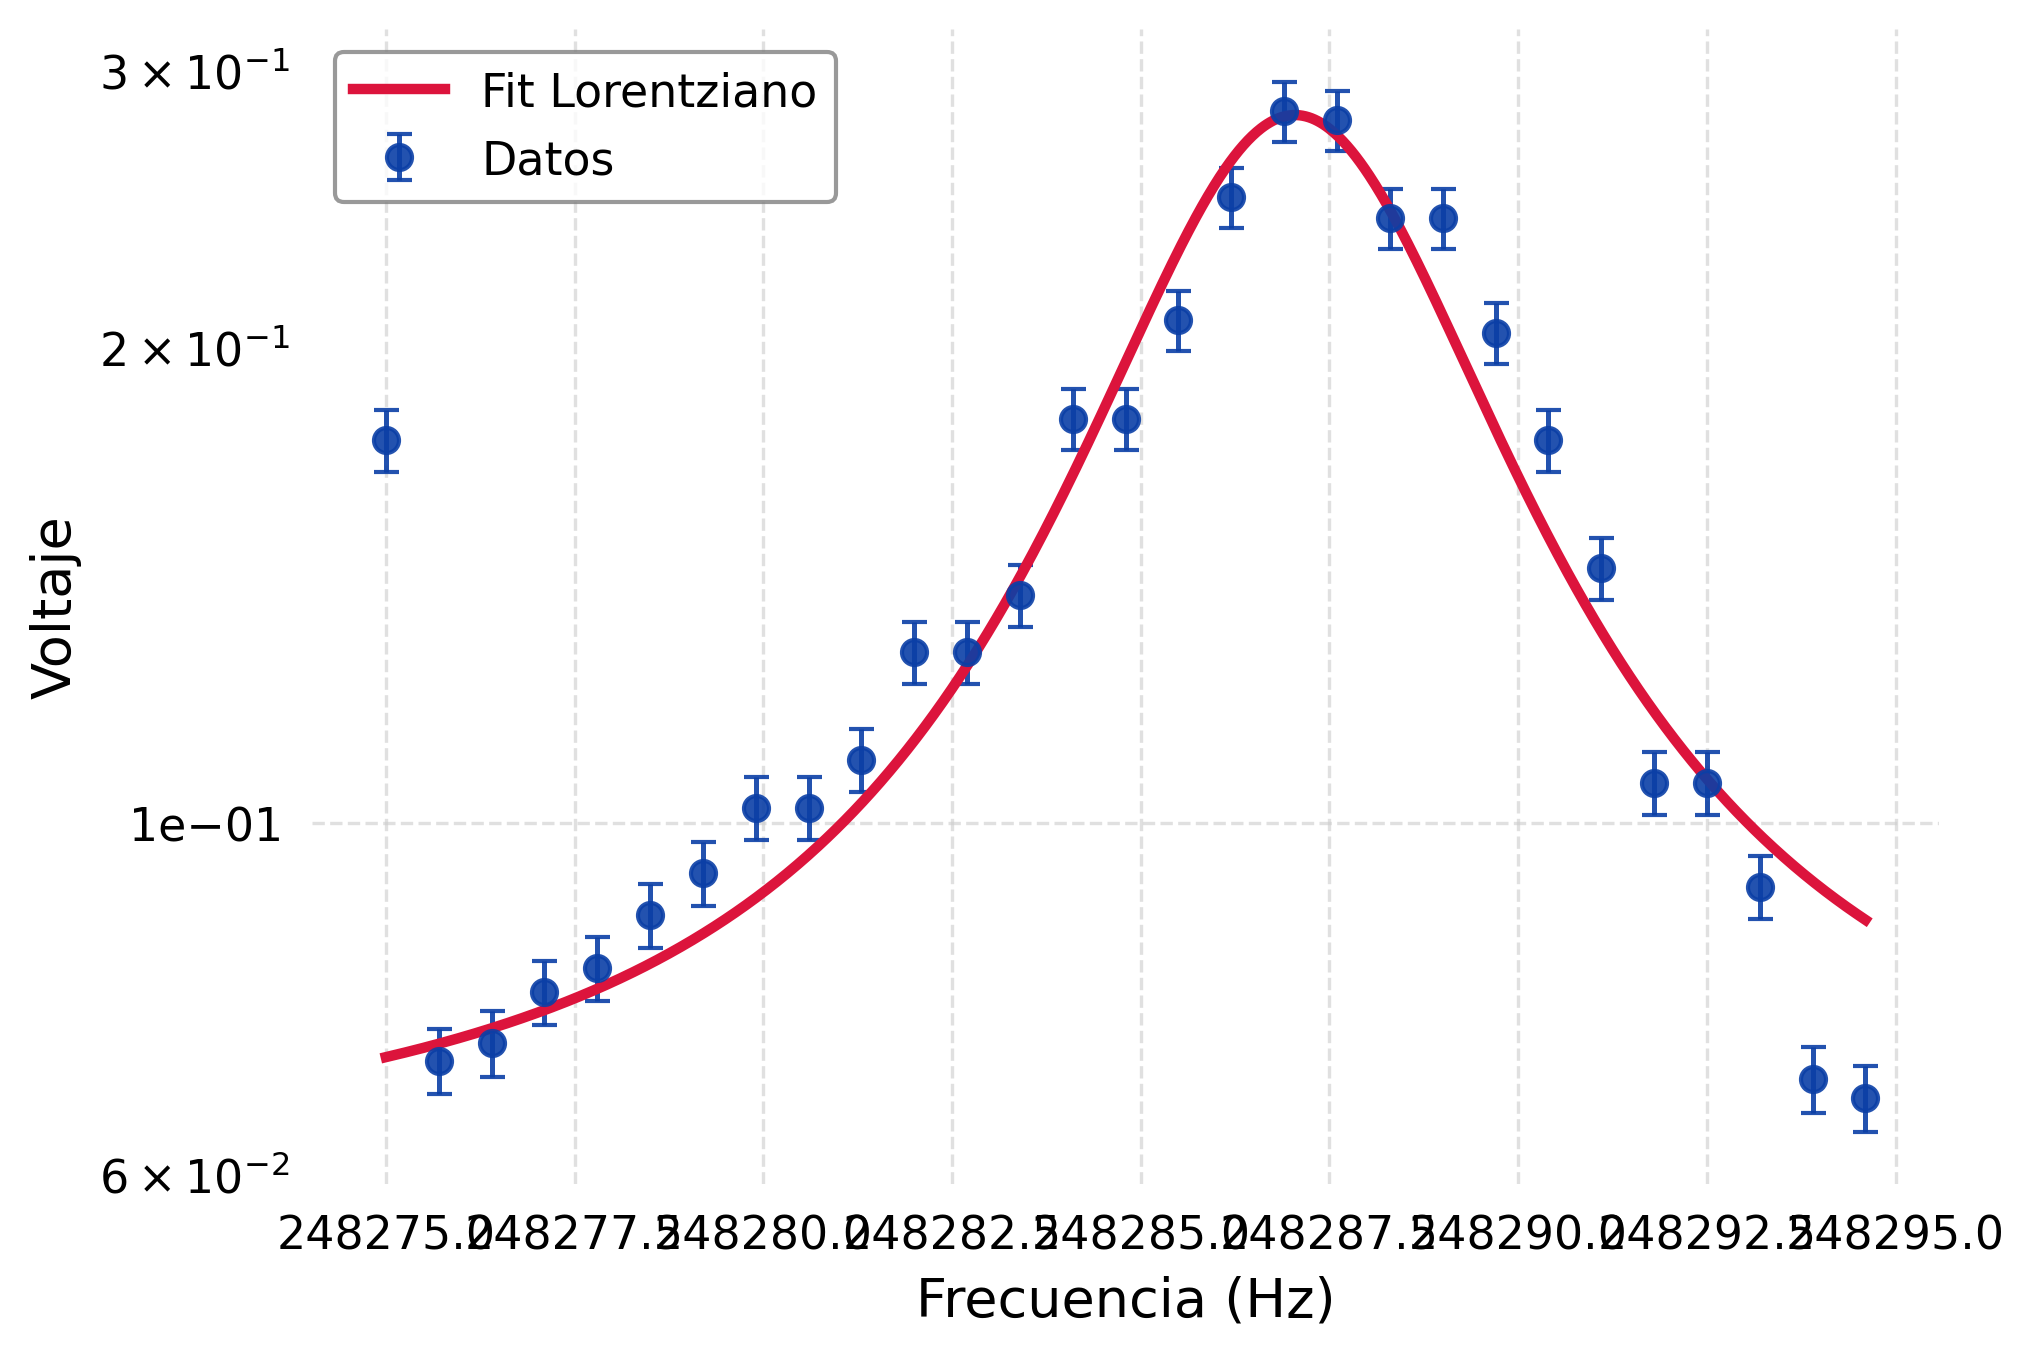

In [9]:
# -------- datos --------
f = np.array(segmented_data_c[0]["freq"])   # o tu array de frecuencias
V2 = np.array(segmented_data_c[0]["v2"]) 
V1 = 2.15     # voltaje
T = V2/V1 
sigma_V2 = 0.03 * V2 + 0.001
sigma_V1 = 0.03 * V1 + 0.001

sigma_T = T * np.sqrt((sigma_V2 / V2)**2 +(sigma_V1 / V1)**2)

# -------- estimaciones iniciales --------
f0_guess = f[np.argmax(T)]
A_guess = max(T) - min(T)
gamma_guess = (max(f) - min(f)) / 10
offset_guess = min(T)

p0 = [f0_guess, gamma_guess, A_guess, offset_guess]

# -------- ajuste --------
popt, pcov = curve_fit(
    lorentzian,
    f,
    T,
    p0=p0,
    sigma=sigma_T,
    absolute_sigma=True,
    maxfev=10000
)

f0, gamma, A, offset = popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
df0, dgamma, dA, doffset = perr

# -------- plot --------

f_fit = np.linspace(min(f), max(f), 1000)
T_fit = lorentzian(f_fit, *popt)

plt.errorbar(
    f, T,
    yerr=sigma_T,
    fmt='o',
    color='#0b3fa6',
    markerfacecolor='#0b3fa650',
    markeredgecolor='#0b3fa6',
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(f_fit, T_fit, '-', color='crimson', linewidth=2.5, label="Fit Lorentziano")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Voltaje")
plt.yscale("log")
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
plt.legend()
plt.show()

In [714]:
R2 = 10000  # ohms (ejemplo, poné el real)

R = R2/Tmax - R2

L = Q * R / (2*np.pi*f0)
C = 1 / ((2*np.pi*f0)**2 * L)

print(f"R = {R:.2e} Ohm")
print(f"L = {L:.2e} H")
print(f"C = {C:.2e} F")

R = 2.56e+04 Ohm
L = 7.16e+02 H
C = 5.74e-16 F


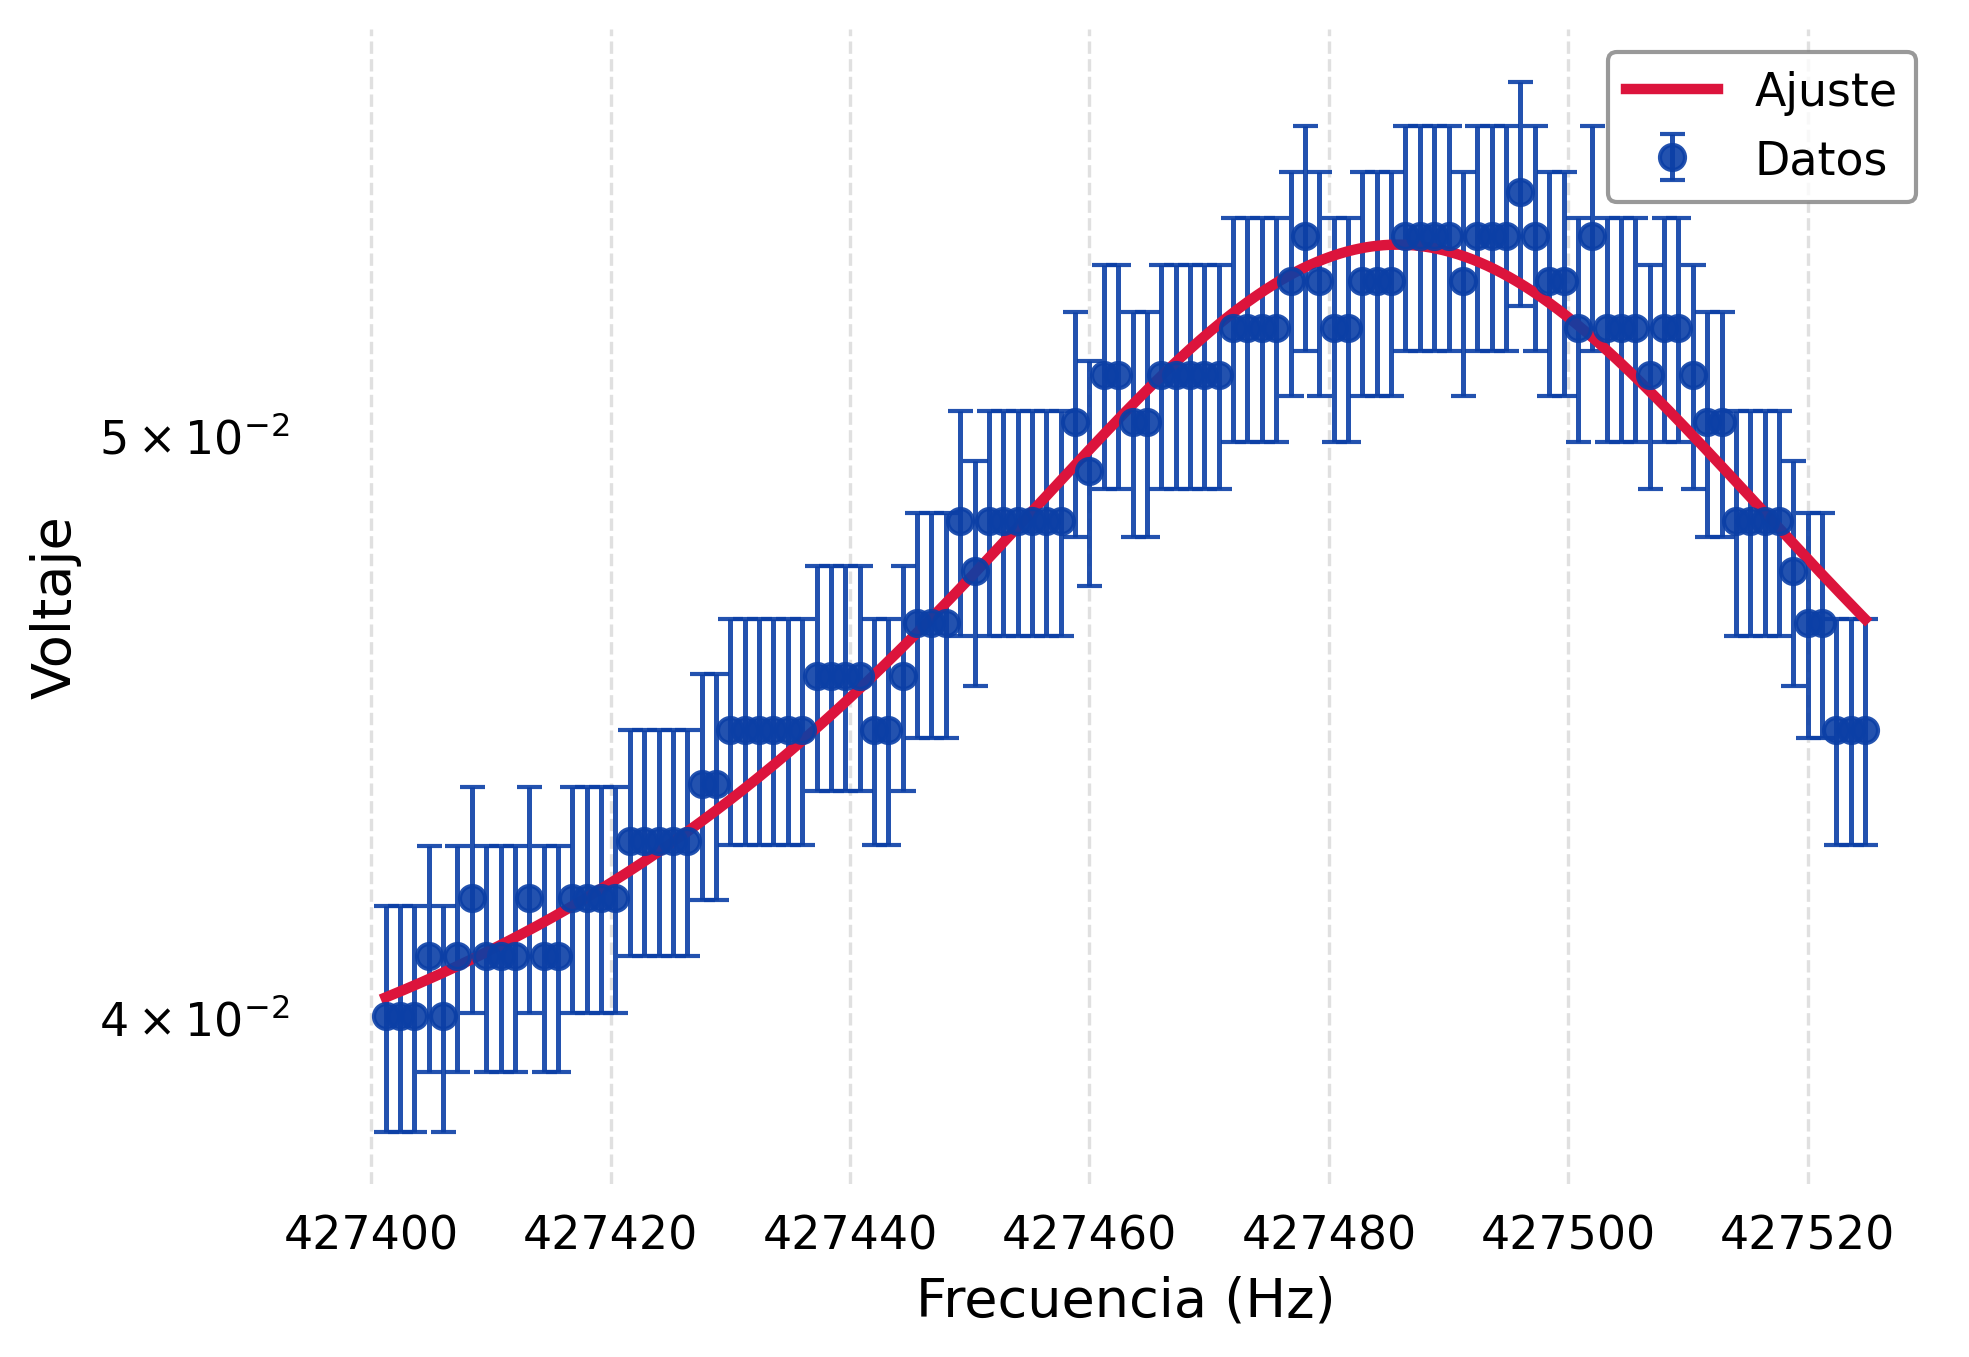

In [11]:
# -------- datos --------
f = np.array(segmented_data_c[1]["freq"])   # o tu array de frecuencias
V2 = np.array(segmented_data_c[1]["v2"])     # voltaje
V1 = 2.15     # voltaje
T = V2/V1 
sigma_V2 = 0.03 * V2 + 0.0001
sigma_V1 = 0.03 * V1 

sigma_T = T * np.sqrt((sigma_V2 / V2)**2 +(sigma_V1 / V1)**2)


mask = (f > 427400) & (f < 427525)   # ajustá este valor

f = f[mask]
T = T[mask]
sigma_T = sigma_T[mask]

# -------- estimaciones iniciales --------
f0_guess = f[np.argmax(T)]
A_guess = max(T)
gamma_guess = (max(f) - min(f)) / 10
offset_guess = min(T)

p0 = [f0_guess, gamma_guess, A_guess, offset_guess]

# -------- ajuste --------
popt, pcov = curve_fit(
    lorentzian,
    f,
    T,
    p0=p0,
    sigma=sigma_T,
    absolute_sigma=True,
    maxfev=10000
)

f0, gamma, A, offset = popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
df0, dgamma, dA, doffset = perr

# -------- plot --------

f_fit = np.linspace(min(f), max(f), 1000)
T_fit = lorentzian(f_fit, *popt)

plt.errorbar(
    f, T,
    yerr=sigma_T,
    fmt='o',
    color='#0b3fa6',
    markerfacecolor='#0b3fa650',
    markeredgecolor='#0b3fa6',
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(f_fit, T_fit, '-', color='crimson', linewidth=2.5, label="Ajuste")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Voltaje")
plt.yscale("log")
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
plt.legend()
plt.show()

In [13]:
file_list = sorted(glob.glob("13h_28m_49s/*.pkl"))

frequencies = []
v1 = []
v2 = []

for file in file_list:
    # -------- extraer frecuencia del nombre --------
    filename = os.path.basename(file)
    freq = float(filename.split("_")[1].replace("Hz.pkl", ""))
    frequencies.append(freq)

    # -------- cargar datos --------
    with open(file, "rb") as f:
        data = pickle.load(f)

        # convertir strings a float
        v1.append(float(data['v1']))
        v2.append(float(data['v2']))
        
segments = [
    (150140,150170, 0.5 ),
    (248275,248295, 0.7),
    (427100,427550, 1.2),
    (558640,560670,20), 
    (648850,650580,30)
]

# convertir a arrays
frequencies = np.array(frequencies)
v1 = np.array(v1)
v2 = np.array(v2)

# lista donde guardar resultados
segmented_data = []

for start, stop, step in segments:
    # máscara: qué datos caen en este intervalo
    mask = (frequencies >= start) & (frequencies <= stop)
    
    seg_freq = frequencies[mask]
    seg_v1 = v1[mask]
    seg_v2 = v2[mask]
    
    segmented_data.append({
        "range": (start, stop),
        "freq": seg_freq,
        "v1": seg_v1,
        "v2": seg_v2
    })

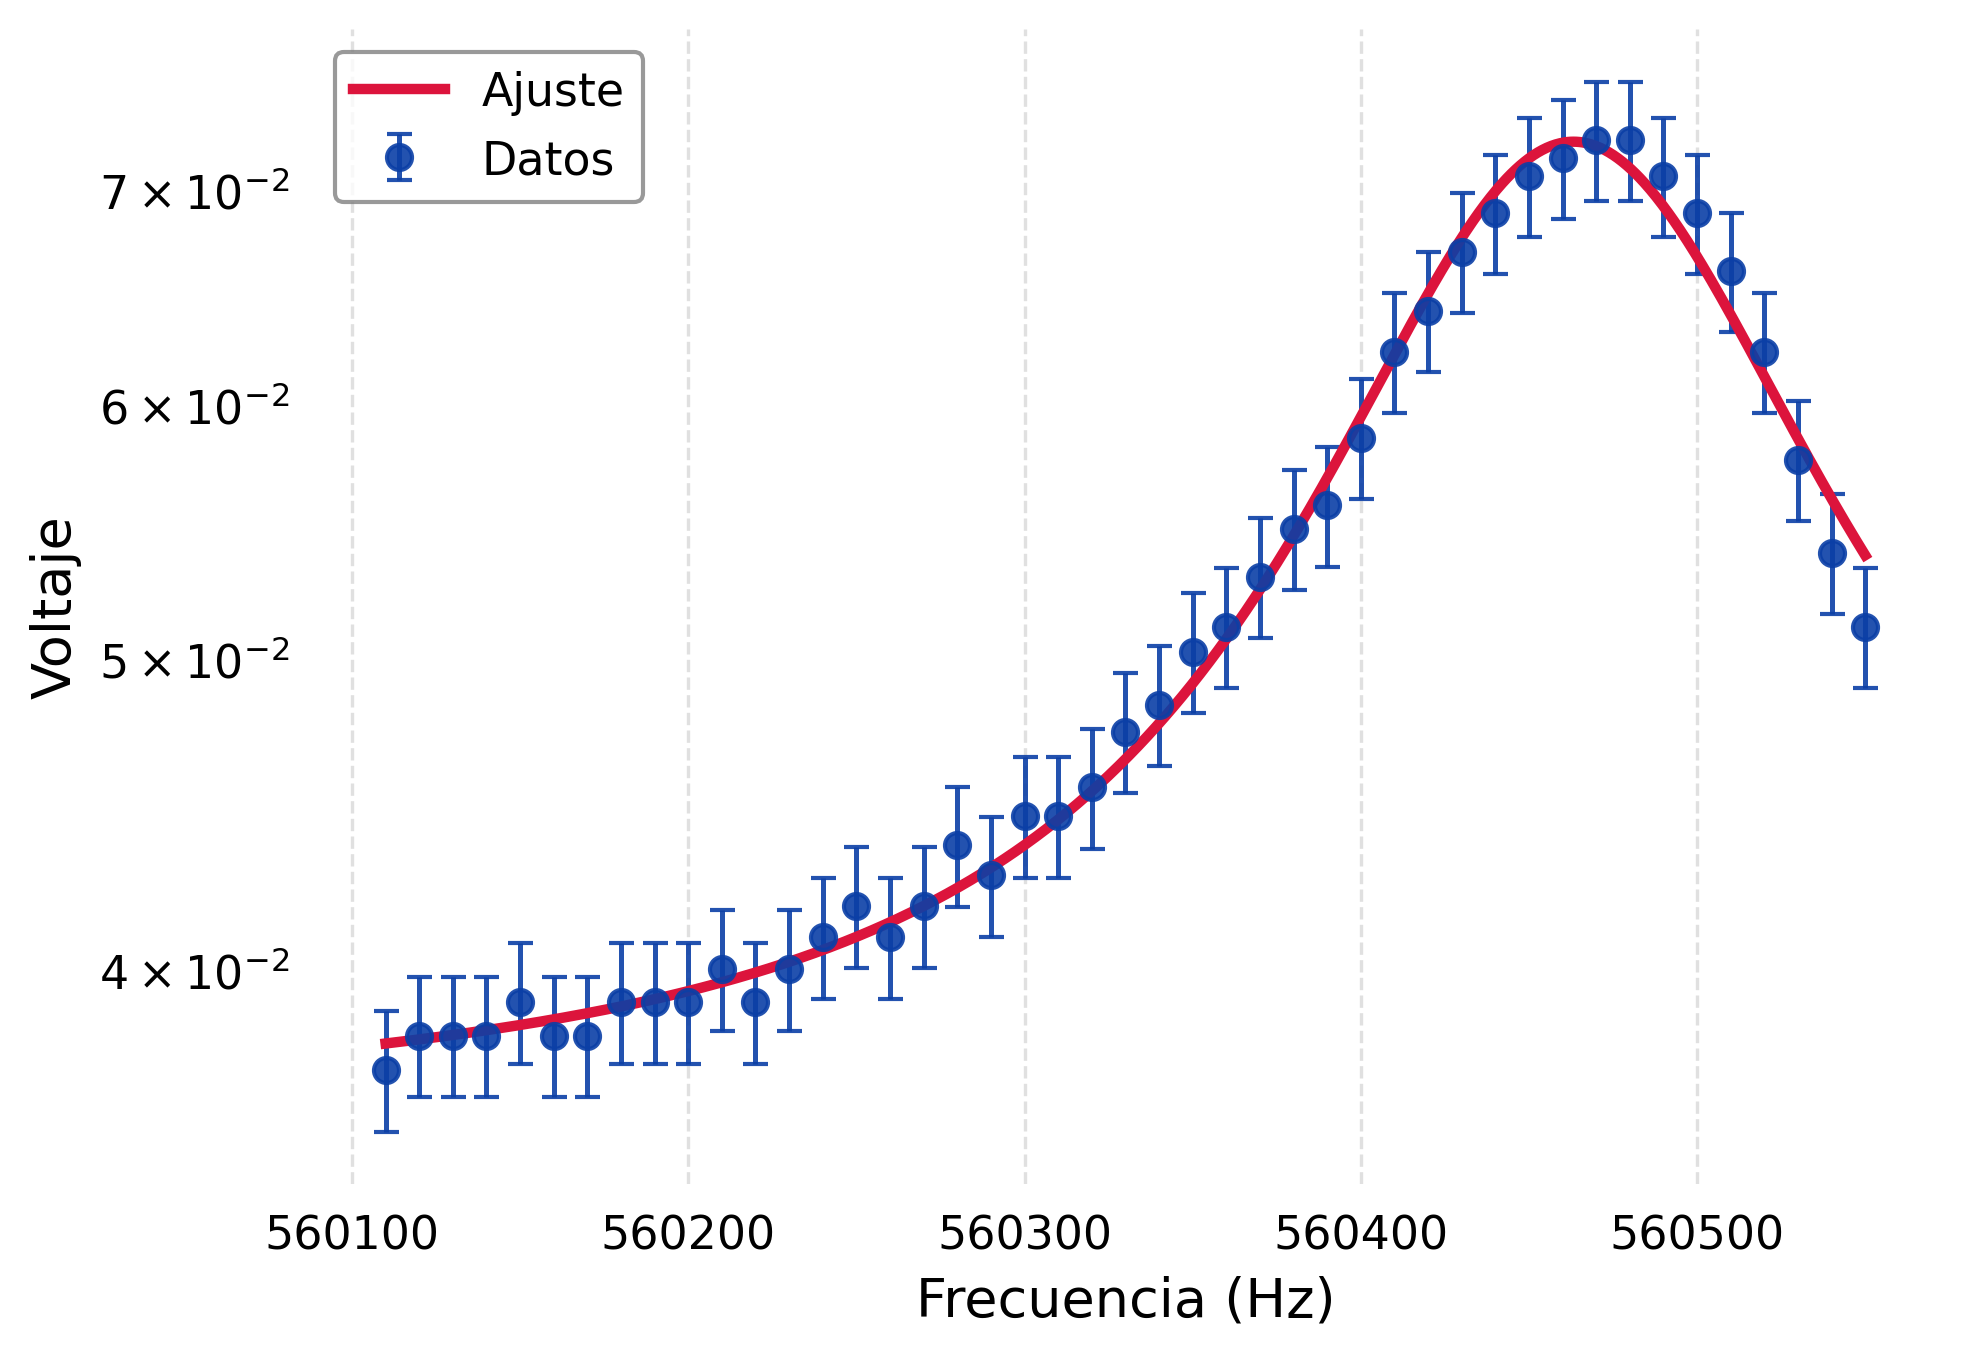

f0 = 560463.26 ± 2.59 Hz
FWHM = 170.27 ± 11.10 Hz
Q = 3291.57 ± 214.52
Tmax = 0.072 ± 0.001 V


In [14]:
# -------- datos --------
f = np.array(segmented_data[3]["freq"])   # o tu array de frecuencias
V2 = np.array(segmented_data[3]["v2"])     # voltaje
V1 = 2.15     # voltaje
T = V2/V1 
sigma_V2 = 0.03 * V2 + 0.0001
sigma_V1 = 0.03 * V1 

sigma_T = T * np.sqrt((sigma_V2 / V2)**2 +(sigma_V1 / V1)**2)


mask = (f > 560100) & (f < 560560)   # ajustá este valor

f = f[mask]
T = T[mask]
sigma_T = sigma_T[mask]

# -------- estimaciones iniciales --------
f0_guess = f[np.argmax(T)]
A_guess = max(T)
gamma_guess = (max(f) - min(f)) / 10
offset_guess = min(T)

p0 = [f0_guess, gamma_guess, A_guess, offset_guess]

# -------- ajuste --------
popt, pcov = curve_fit(
    lorentzian,
    f,
    T,
    p0=p0,
    sigma=sigma_T,
    absolute_sigma=True,
    maxfev=10000
)

f0, gamma, A, offset = popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
df0, dgamma, dA, doffset = perr

# -------- plot --------

f_fit = np.linspace(min(f), max(f), 1000)
T_fit = lorentzian(f_fit, *popt)

plt.errorbar(
    f, T,
    yerr=sigma_T,
    fmt='o',
    #color='black',        # puntos
    #ecolor='gray',        # barras de error
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(f_fit, T_fit, '-', label="Ajuste",color='crimson')
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Voltaje")
plt.yscale("log")
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
plt.legend()
plt.grid(True)
plt.show()

f_res = f0
df_res = df0
Tmax = lorentzian(f0, *popt)
dTmax = np.sqrt(dA**2 + doffset**2)
FWHM = 2 * gamma
dFWHM = 2 * dgamma
Q = f0 / FWHM
dQ = Q * np.sqrt((df0/f0)**2 + (dFWHM/FWHM)**2)

print(f"f0 = {f0:.2f} ± {df0:.2f} Hz")
print(f"FWHM = {FWHM:.2f} ± {dFWHM:.2f} Hz")
print(f"Q = {Q:.2f} ± {dQ:.2f}")
print(f"Tmax = {Tmax:.3f} ± {dTmax:.3f} V")

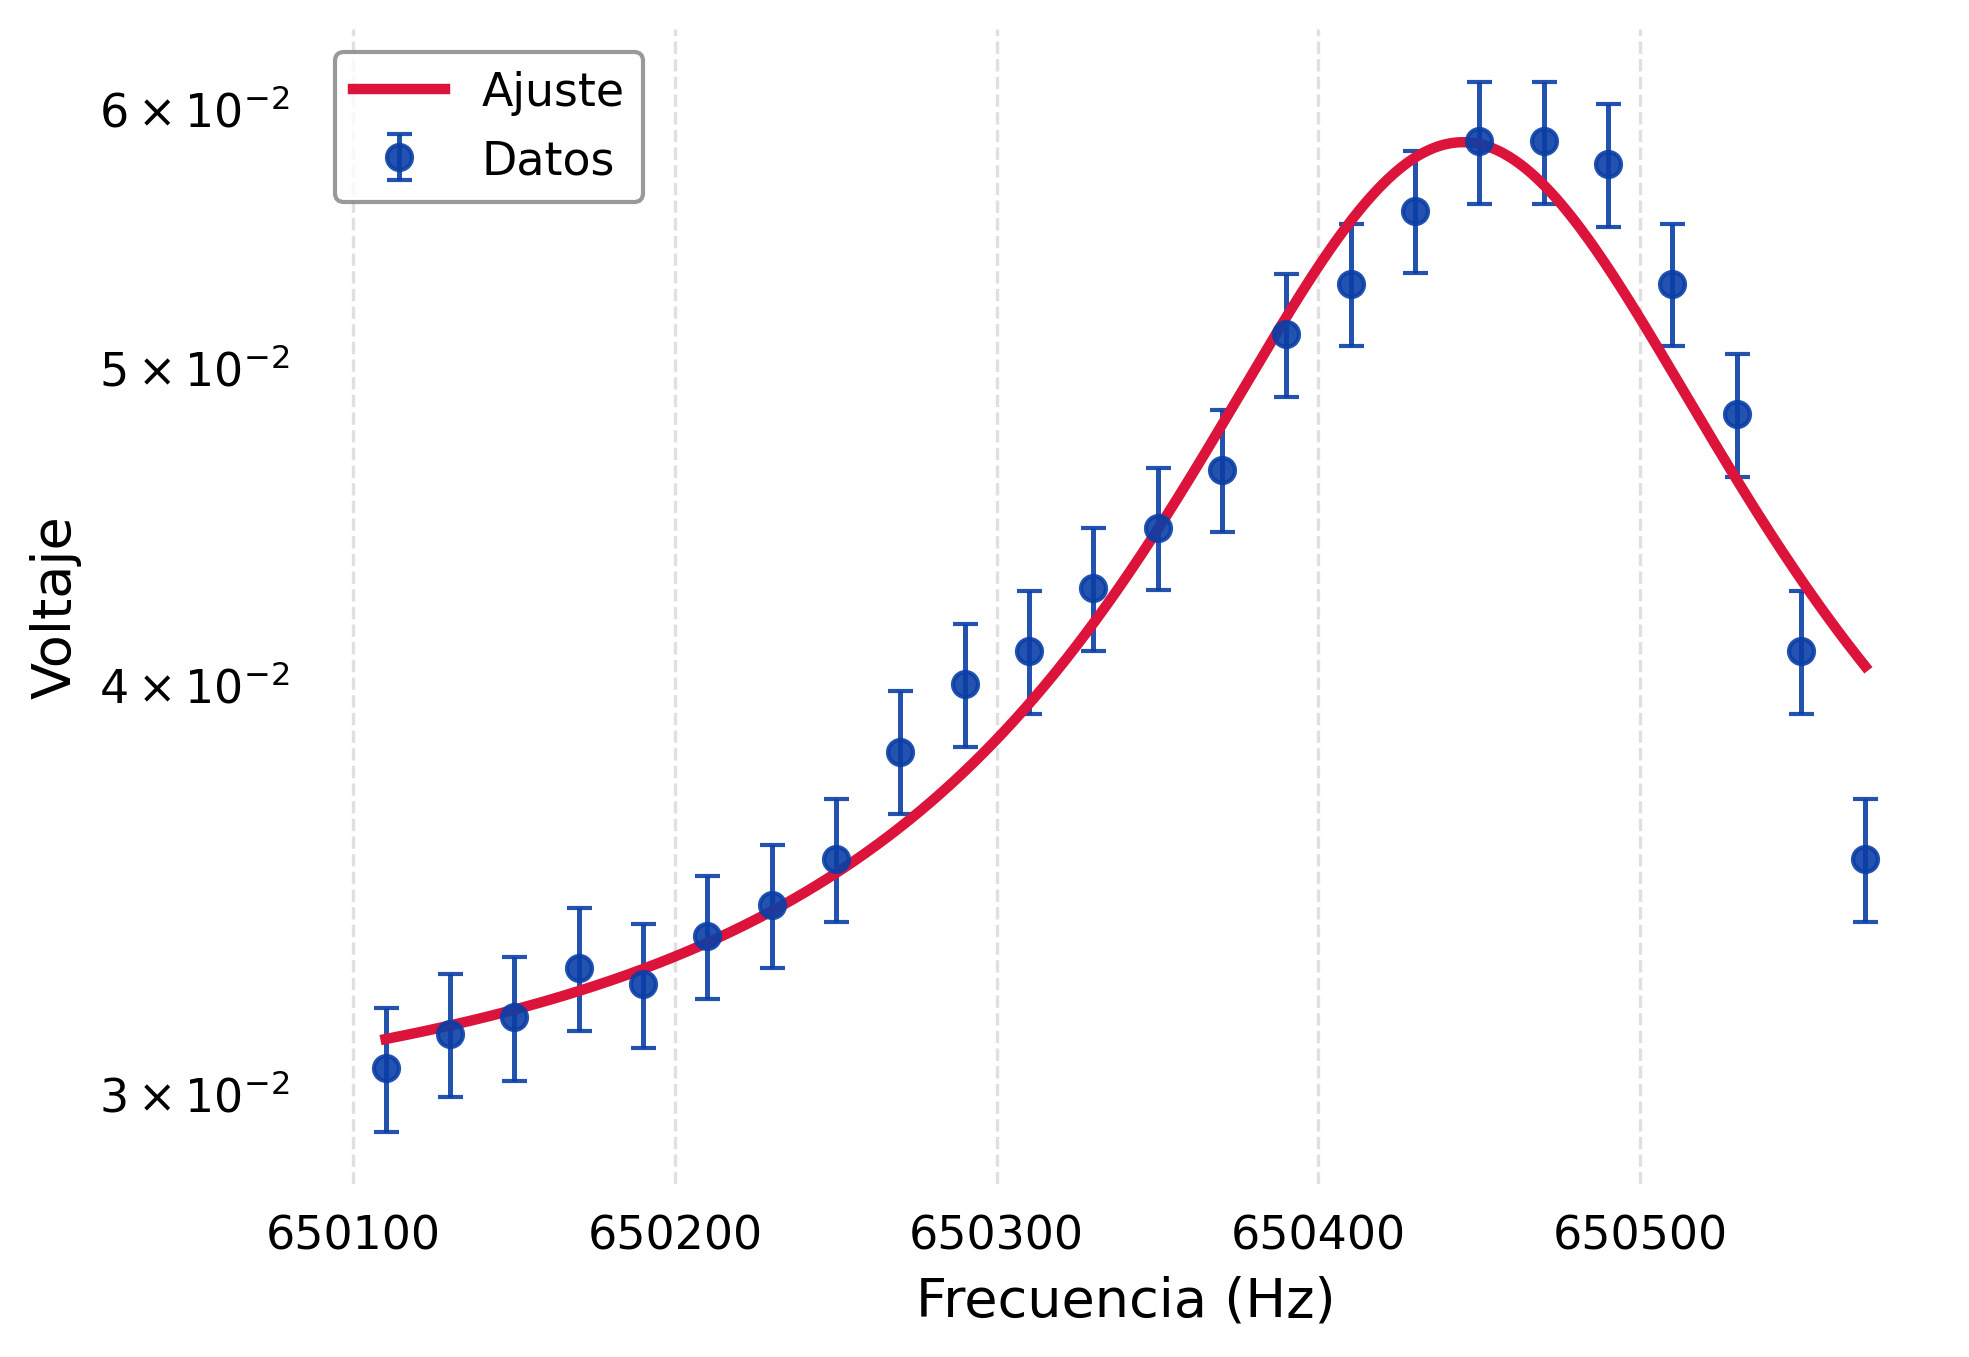

In [16]:
# -------- datos --------
f = np.array(segmented_data[4]["freq"])   # o tu array de frecuencias
V2 = np.array(segmented_data[4]["v2"])     # voltaje
V1 = 2.15     # voltaje
T = V2/V1 
sigma_V2 = 0.03 * V2 + 0.0001
sigma_V1 = 0.03 * V1 

sigma_T = T * np.sqrt((sigma_V2 / V2)**2 +(sigma_V1 / V1)**2)


mask = (f > 650100) & (f < 660600)   # ajustá este valor

f = f[mask]
T = T[mask]
sigma_T = sigma_T[mask]

# -------- estimaciones iniciales --------
f0_guess = f[np.argmax(T)]
A_guess = max(T)
gamma_guess = (max(f) - min(f)) / 10
offset_guess = min(T)

p0 = [f0_guess, gamma_guess, A_guess, offset_guess]

# -------- ajuste --------
popt, pcov = curve_fit(
    lorentzian,
    f,
    T,
    p0=p0,
    sigma=sigma_T,
    absolute_sigma=True,
    maxfev=10000
)

f0, gamma, A, offset = popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
df0, dgamma, dA, doffset = perr

# -------- plot --------

f_fit = np.linspace(min(f), max(f), 1000)
T_fit = lorentzian(f_fit, *popt)

plt.errorbar(
    f, T,
    yerr=sigma_T,
    fmt='o',
    color='#0b3fa6',
    markerfacecolor='#0b3fa650',
    markeredgecolor='#0b3fa6',
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(f_fit, T_fit, '-', color='crimson', linewidth=2.5, label="Ajuste")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Voltaje")
plt.yscale("log")
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
plt.legend()
plt.show()

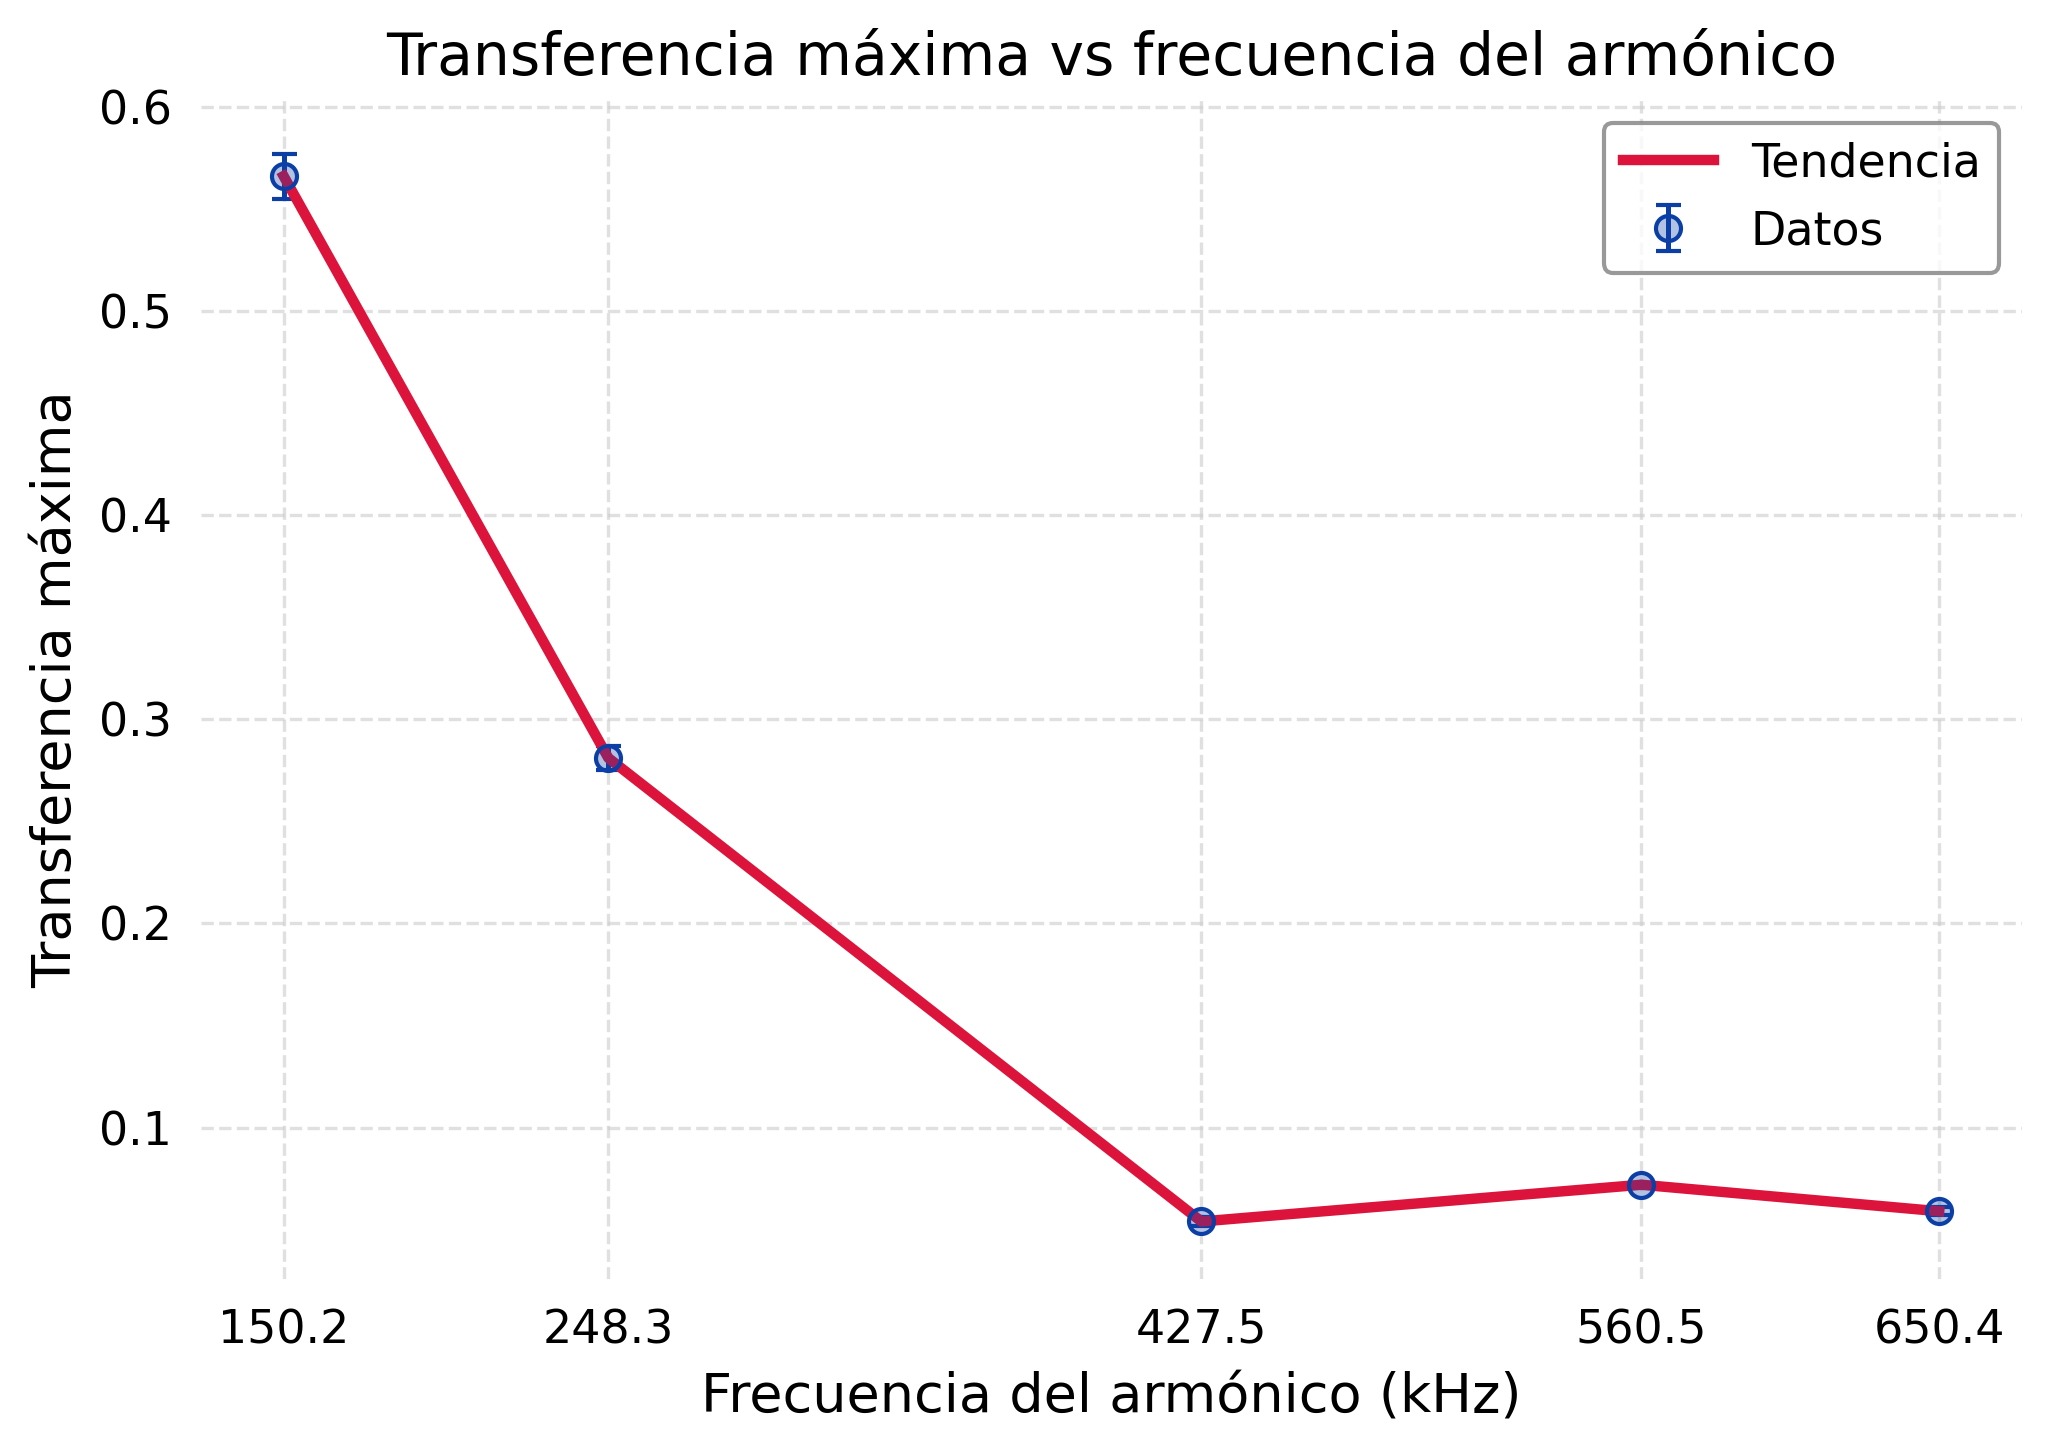

In [17]:
Ts_max = [0.566,0.281,0.054,0.072,0.059]
Ts_max_errs = [0.011,0.006, 0.002,0.001,0.002]
frecs_modos = [150160.48,248287.04,427475.85,560463.26,650444.91]
frecs_modos_errs = [0.04, 0.06, 1.26, 2.59,3.69]

freqs_kHz = np.array(frecs_modos) / 1000  

plt.figure(figsize=(7,5))

plt.errorbar(
    freqs_kHz, Ts_max, 
    yerr=Ts_max_errs, 
    fmt='o', 
    color='#0b3fa6', 
    markerfacecolor='#0b3fa650', 
    markeredgecolor='#0b3fa6',
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    label="Datos"
)

# línea suave para guiar la vista
plt.plot(freqs_kHz, Ts_max, '-', color='crimson', linewidth=2.5, label="Tendencia")

plt.xlabel("Frecuencia del armónico (kHz)")
plt.xticks(freqs_kHz)
plt.ylabel("Transferencia máxima")
plt.title("Transferencia máxima vs frecuencia del armónico")
plt.legend()
plt.tight_layout()
plt.show()

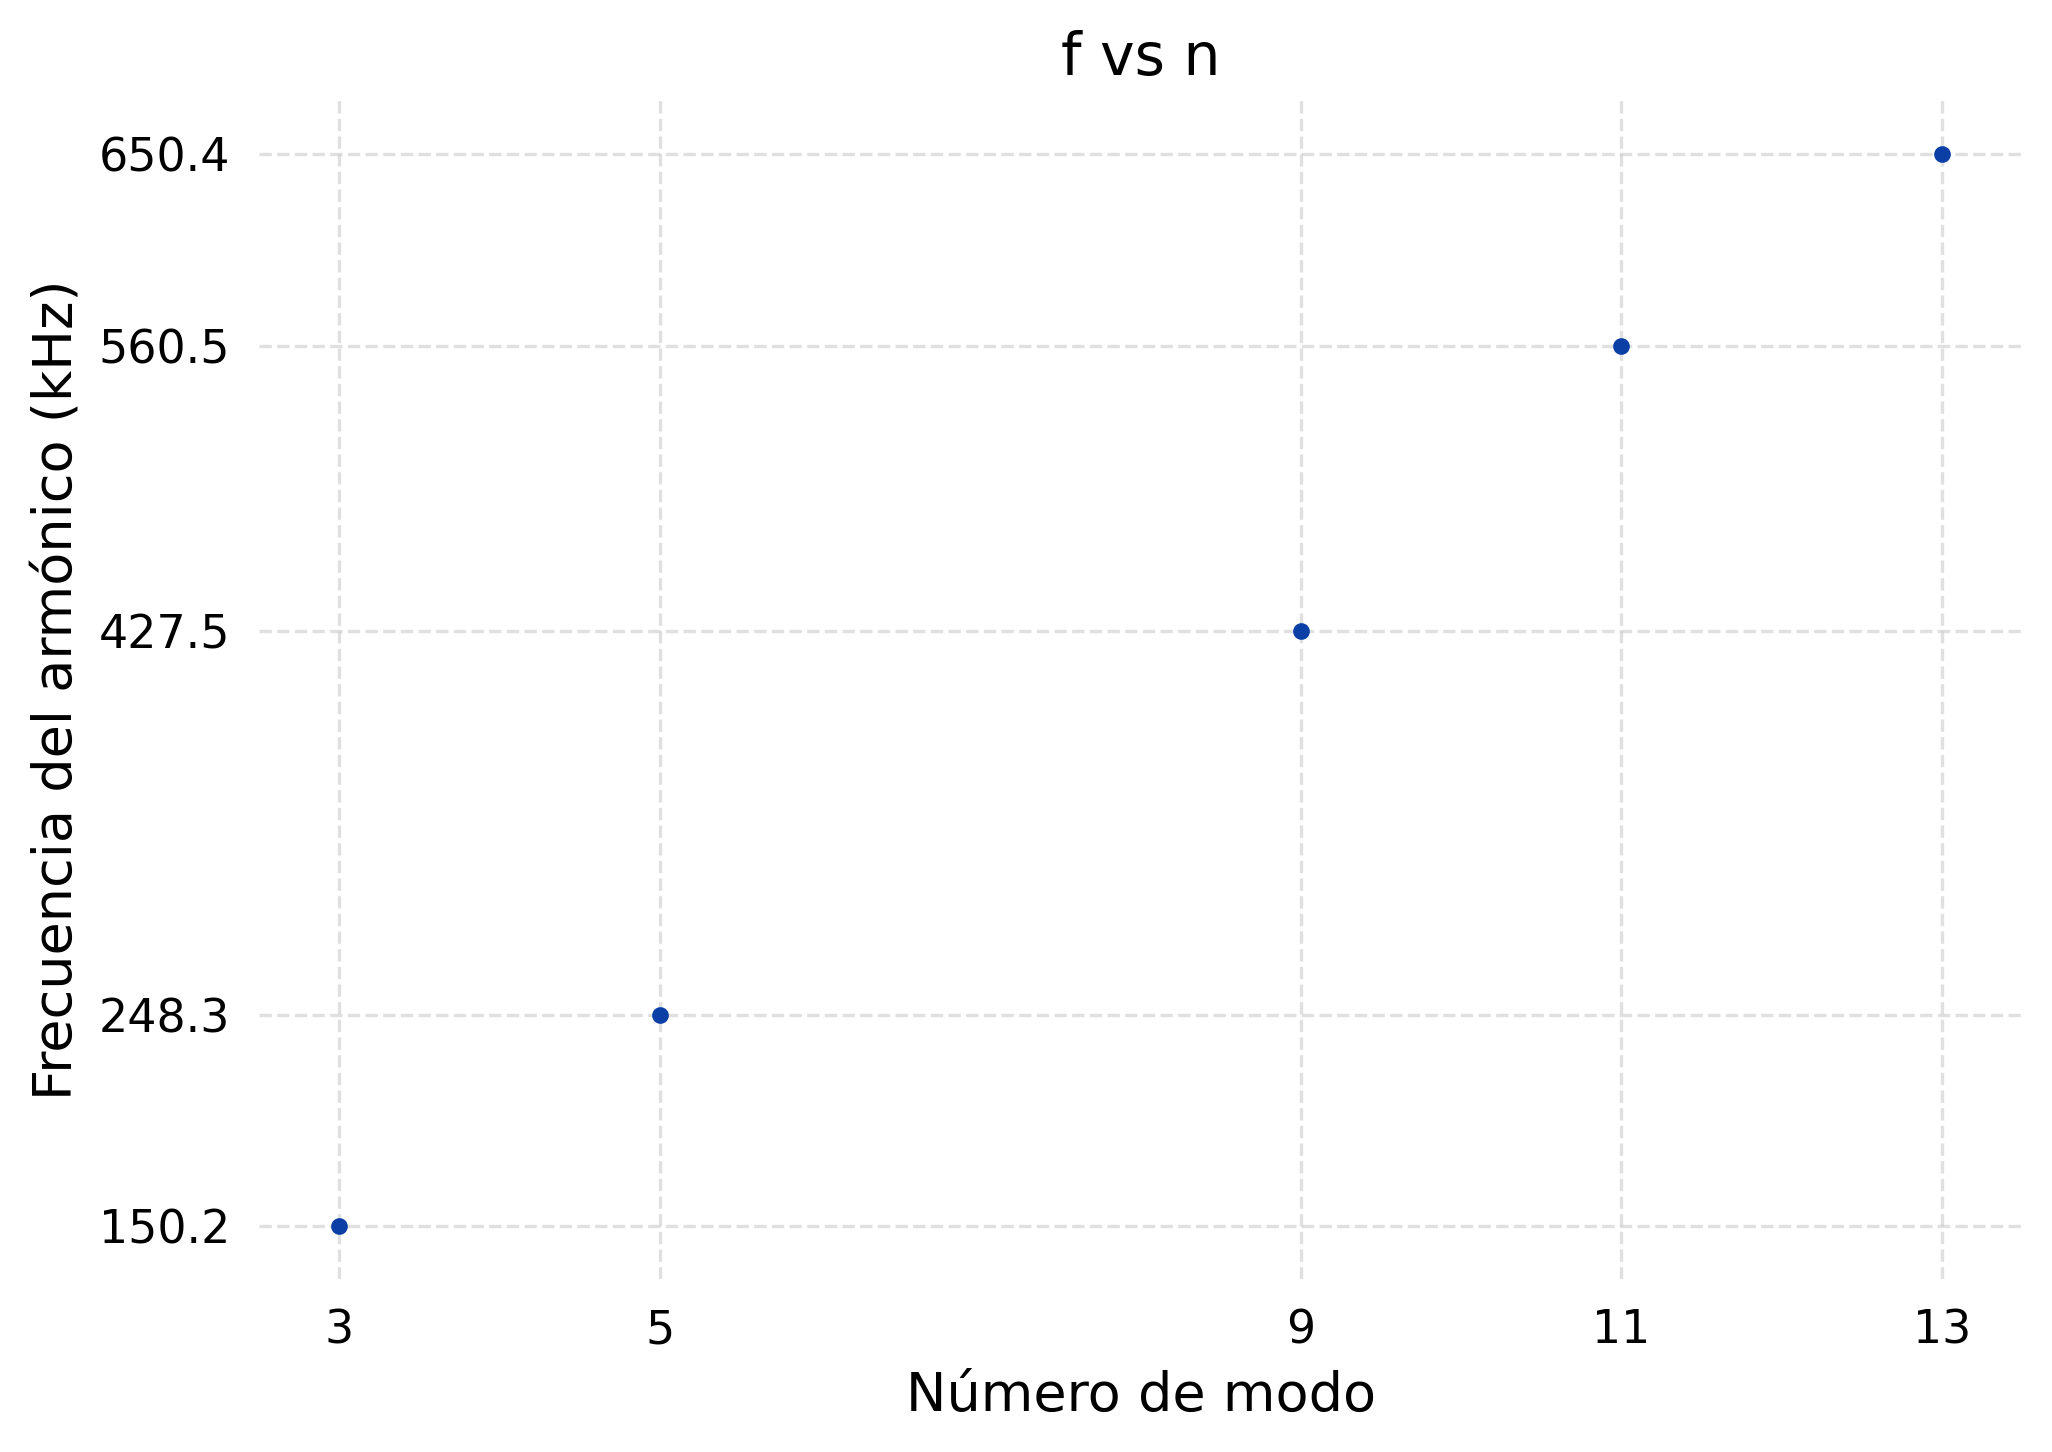

In [20]:
ns = [ 3, 5, 9, 11, 13]

plt.figure(figsize=(7,5))

plt.errorbar(ns, freqs_kHz, yerr=np.array(frecs_modos_errs)/1000, fmt='.')

plt.ylabel("Frecuencia del armónico (kHz)")
plt.xticks(ns)
plt.yticks(freqs_kHz)
plt.xlabel("Número de modo")
plt.title("f vs n")
plt.tight_layout()
plt.grid(True)
plt.show()

In [21]:
vs_f = []

for i in range(len(ns)):
    L = 4e-3
    f = frecs_modos[i]
    n = ns[i]
    v_f =  4 * L * f / n
    print("La velocidad de fase en el modo " + str(i) +" es: ", v_f)
    vs_f.append(v_f)

La velocidad de fase en el modo 0 es:  800.8558933333334
La velocidad de fase en el modo 1 es:  794.5185280000001
La velocidad de fase en el modo 2 es:  759.9570666666666
La velocidad de fase en el modo 3 es:  815.2192872727272
La velocidad de fase en el modo 4 es:  800.5475815384616


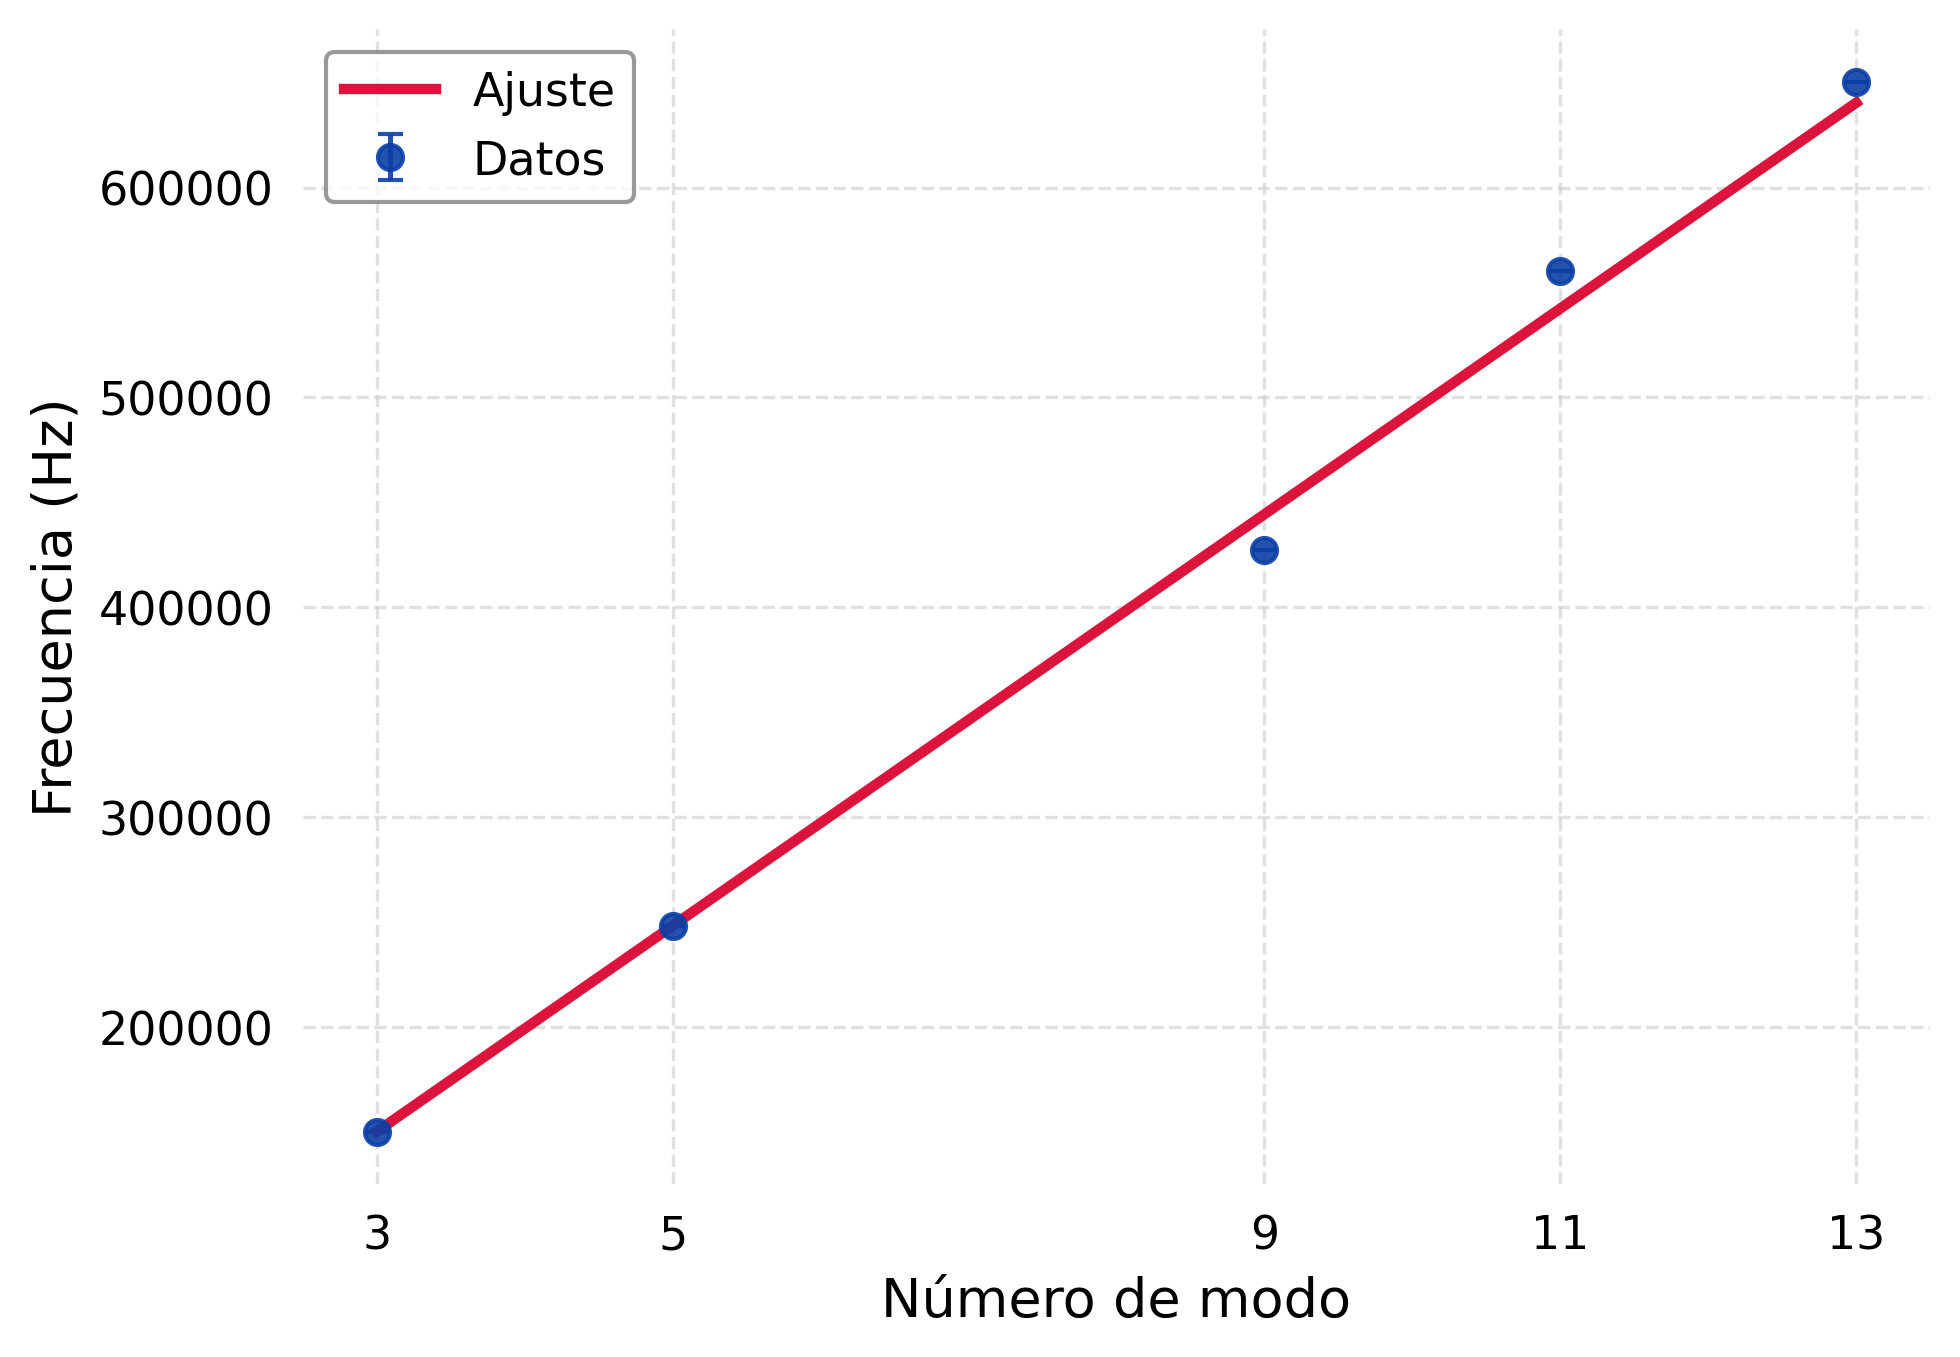

v_f = 784.38 ± 0.0005649579952462795 m/s


In [22]:
def lineal(x,a,b):
    return a*x +b

ns = np.array(ns)
frecs_modos = np.array(frecs_modos)
frecs_modos_errs = np.array(frecs_modos_errs)

# -------- ajuste --------
popt, pcov = curve_fit(lineal,ns,frecs_modos,sigma=frecs_modos_errs, absolute_sigma=True, maxfev=10000)
a, b= popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
da,db= perr

def lineal(x,a,b):
    return a*x +b

ns = np.array(ns)
frecs_modos = np.array(frecs_modos)
frecs_modos_errs = np.array(frecs_modos_errs)

# -------- ajuste --------
popt, pcov = curve_fit(lineal,ns,frecs_modos,sigma=frecs_modos_errs, absolute_sigma=True, maxfev=10000)
a, b= popt

# errores de parámetros
perr = np.sqrt(np.diag(pcov))
da,db= perr

# -------- plot --------

plt.errorbar(
    ns, frecs_modos,
    yerr=frecs_modos_errs,
    fmt='o',
    color='#0b3fa6',
    markerfacecolor='#0b3fa650',
    markeredgecolor='#0b3fa6',
    elinewidth=1.2,
    capsize=3,
    capthick=1,
    alpha=0.9,
    label="Datos"
)
plt.plot(ns, lineal(ns, a, b), '-', color='crimson', linewidth=2.5, label="Ajuste")
plt.ylabel("Frecuencia (Hz)")
plt.xlabel("Número de modo")
plt.xticks(ns)
plt.legend()
plt.show()

print(f"v_f = {a*4*4*1e-3:.2f} ± {da*4*4*1e-3} m/s")